### 特徵抓取與模型訓練

In [117]:
#!/usr/bin/env python3
import time, json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, top_k_accuracy_score
import warnings
import pickle


warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
warnings.filterwarnings("ignore", category=DeprecationWarning)

class FPNode:
    """A node in an FP-tree."""
    def __init__(self, code=None):
        self.code = code
        self.count = 0
        self.children = {}

def main():
    results = {}
    # --- 1. 載入資料---
    t0 = time.time()
    # transfer t0 to utc -4 time
    print("Loading dataset...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t0 - 14400)))
    
    dataset = f'./data/dataset_{num_items}_items.csv'

    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    # txns = [[i for i in t if i != '-1' and i != ''] for t in txns]
    txns = [
        [item.strip() for item in txn
        if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    freq_counter = Counter(i for t in txns for i in t)
    unique_items = sorted(freq_counter)
    print(">> Unique items:", freq_counter, "count =", len(unique_items), flush=True)

    enc = LabelEncoder(); enc.fit(unique_items)
    N = len(txns)
    results['num_txns'] = N
    results['num_items'] = len(unique_items)
    results['preproc_time_s'] = time.time() - t0

    # --- 2. 特徵抽取 ---
    t1 = time.time()
    print("Extracting features...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t1 - 14400)))
    # real_root = type('FPNode', (), {'__init__': lambda s,code=None: setattr(s, 'children', {}) or setattr(s, 'count',0) or setattr(s,'code',code)})()
    real_root = FPNode()
    real_root.count = 0
    features, labels = [], []
    for txn in txns:
        seq = sorted(txn, key=lambda x:-freq_counter[x])
        codes = enc.transform(seq)
        node = real_root; node.count += 1; prefix = []
        for c in codes:
            # build feature vector
            pv = np.zeros(len(unique_items), int)
            for p in prefix: pv[p] = 1
            
            cc = np.zeros(len(unique_items), int)
            for ch, nd in node.children.items(): cc[ch] = nd.count
            
            pc, pl = node.count, len(prefix)
            
            item = enc.inverse_transform([c])[0]
            
            p_c = freq_counter[item]/N


            # p_p = freq_counter[prefix[-1]]/N if prefix else 1.0
            if prefix:
                last_code = prefix[-1]
                last_item = enc.inverse_transform([last_code])[0]
                p_p = freq_counter[last_item] / N
            else:
                p_p = 1.0
            
            edge_ct = node.children.get(c, type(node)()).count
            p_edge = edge_ct / N
            p_bound = p_c * p_p * p_edge

            feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
            features.append(feat); labels.append(c)

            # 插入節點
            if c not in node.children:
                nd = type(node)(code=c)
                nd.count = 0
                node.children[c] = nd
            node = node.children[c]; node.count += 1
            prefix.append(c)
            
            # if len(features) < 5:
            #     print("DBG:", item, p_c, p_p, p_edge, p_bound, flush=True)

    real_root.count = N
    X = np.array(features); y = np.array(labels)
    results['feature_count'] = X.shape[0]
    results['feature_time_s'] = time.time() - t1

    

    # --- 3. XGBoost 依商品拆分模型 ---
    t2 = time.time()
    print("Training models...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t2 - 14400)))
    tr, te = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42)
    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]

    item_models = {}
    for code in range(len(unique_items)):
        yb = (y_tr == code).astype(int)
        if yb.sum() < 30: continue
        mdl = XGBClassifier(
           objective='binary:logistic',
           use_label_encoder=False, eval_metric='logloss',
           n_estimators=100, max_depth=6, learning_rate=0.1
        )
        mdl.fit(X_tr, yb)
        item_models[code] = mdl
    results['num_trained_models'] = len(item_models)
    results['train_time_s'] = time.time() - t2

    # --- 4. 預測 & 評估 ---
    t3 = time.time()
    print("Evaluating models...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t3 - 14400)))
    proba = np.zeros((len(te), len(unique_items)))
    for i, idx in enumerate(te):
        xi = X[idx].reshape(1, -1)
        for c, m in item_models.items():
            proba[i, c] = m.predict_proba(xi)[0,1]
    acc1 = accuracy_score(y_te, proba.argmax(axis=1))
    # acc3 = top_k_accuracy_score(y_te, proba, k=3)
    results.update({
        'top1_acc': acc1,
        'top2_acc': top_k_accuracy_score(y_te, proba, k=2),
        'top3_acc': top_k_accuracy_score(y_te, proba, k=3),
        'top4_acc': top_k_accuracy_score(y_te, proba, k=4),
        'top5_acc': top_k_accuracy_score(y_te, proba, k=5),
    })
    results['eval_time_s'] = time.time() - t3

    # --- 5. 輸出結果 ---
    # 存 JSON
    with open('results_summary.json', 'w') as f:
        json.dump(results, f, indent=2)
    # Bash 輸出
    print("--- Results Summary ---")
    for k,v in results.items():
        print(f"{k:20s}: {v}")

    # --- 6. 保存模型與所需物件 ---
    
    print("Saving model artifacts...", flush=True)
    artifacts = {
        'models': item_models,
        'encoder': enc,
        'freq_counter': freq_counter,
        'real_root': real_root,
        'num_total_txns': N,
        'unique_items': unique_items
    }
    
    with open(f'fp_model_artifacts_{num_items}.pkl', 'wb') as f:
        pickle.dump(artifacts, f)
        
    print(f"Artifacts saved to fp_model_artifacts_{num_items}.pkl")

if __name__ == '__main__':
    
    num_items = 12  # 預設的項目數量
    main()

# 36
# Loading dataset... 2025-07-07 00:25:55
# >> Unique items: Counter({'1787079': 2492, '1787583': 2476, '21212': 1833, '470883': 1739, '998886': 1723, '22457': 1604, '435225': 1558, '470043': 1275, '477120': 1267, '435267': 1252, '466137': 1232, '1782459': 1205, '470106': 1188, '460551': 1170, '487263': 1170, '470631': 1148, '435288': 1136, '470022': 1107, '470064': 1087, '482181': 1076, '482160': 1073, '476679': 1065, '487389': 1065, '475986': 1061, '489258': 1049, '471849': 1039, '476637': 1009, '1732122': 979, '482853': 977, '463806': 907, '477267': 883, '1786029': 852, '1784937': 761, '1784370': 739, '316176': 658, '1776516': 601}) count = 36
# Extracting features... 2025-07-07 00:25:55
# Training models... 2025-07-07 00:26:04
# Evaluating models... 2025-07-07 00:26:27
# --- Results Summary ---
# num_txns            : 9677
# num_items           : 36
# preproc_time_s      : 0.22132539749145508
# feature_count       : 43456
# feature_time_s      : 9.559123039245605
# num_trained_models  : 36
# train_time_s        : 22.558951139450073
# top1_acc            : 0.5724804417855499
# top2_acc            : 0.7070869765301426
# top3_acc            : 0.7811780947998159
# top4_acc            : 0.8349056603773585
# top5_acc            : 0.866889093419236
# eval_time_s         : 222.93091249465942

# 12
# Loading dataset... 2025-07-07 00:38:31
# >> Unique items: Counter({'1787583': 2091, '1787079': 1830, '21212': 1639, '22457': 1444, '998886': 1416, '435225': 1276, '470883': 1266, '477120': 1025, '1782459': 967, '1786029': 720, '1784937': 651, '1776516': 537}) count = 12
# Extracting features... 2025-07-07 00:38:31
# Training models... 2025-07-07 00:38:34
# Evaluating models... 2025-07-07 00:38:38
# --- Results Summary ---
# num_txns            : 5238
# num_items           : 12
# preproc_time_s      : 0.13100981712341309
# feature_count       : 14862
# feature_time_s      : 2.687652111053467
# num_trained_models  : 12
# train_time_s        : 4.379816055297852
# top1_acc            : 0.837874201143626
# top2_acc            : 0.9519004372687521
# top3_acc            : 0.9835183316515305
# top4_acc            : 0.9949545913218971
# top5_acc            : 0.9973091153716784
# eval_time_s         : 30.321168422698975
# Saving model artifacts...
# Artifacts saved to fp_model_artifacts.pkl

# 24
# Loading dataset... 2025-07-07 00:39:42
# >> Unique items: Counter({'1787079': 2452, '1787583': 2313, '21212': 1762, '998886': 1576, '22457': 1545, '435225': 1527, '470883': 1451, '470043': 1259, '435267': 1224, '470106': 1170, '466137': 1168, '477120': 1164, '460551': 1163, '470631': 1128, '435288': 1119, '487263': 1101, '1782459': 1096, '470022': 1081, '471849': 992, '482160': 971, '463806': 848, '1786029': 823, '1784937': 730, '1776516': 579}) count = 24
# Extracting features... 2025-07-07 00:39:42
# Training models... 2025-07-07 00:39:47
# Evaluating models... 2025-07-07 00:39:56
# --- Results Summary ---
# num_txns            : 7864
# num_items           : 24
# preproc_time_s      : 0.1052236557006836
# feature_count       : 30242
# feature_time_s      : 4.9420084953308105
# num_trained_models  : 24
# train_time_s        : 8.57649540901184
# top1_acc            : 0.659943792362374
# top2_acc            : 0.801124152752521
# top3_acc            : 0.8636138204661927
# top4_acc            : 0.9046123326169615
# top5_acc            : 0.9330467845924947
# eval_time_s         : 100.61779856681824
# Saving model artifacts...
# Artifacts saved to fp_model_artifacts.pkl


Loading dataset... 2025-07-11 00:47:10
>> Unique items: Counter({'1787583': 2091, '1787079': 1830, '21212': 1639, '22457': 1444, '998886': 1416, '435225': 1276, '470883': 1266, '477120': 1025, '1782459': 967, '1786029': 720, '1784937': 651, '1776516': 537}) count = 12
Extracting features... 2025-07-11 00:47:10
Training models... 2025-07-11 00:47:13
Evaluating models... 2025-07-11 00:47:16
--- Results Summary ---
num_txns            : 5238
num_items           : 12
preproc_time_s      : 0.08538961410522461
feature_count       : 14862
feature_time_s      : 2.426081418991089
num_trained_models  : 12
train_time_s        : 2.6865527629852295
top1_acc            : 0.837874201143626
top2_acc            : 0.9519004372687521
top3_acc            : 0.9835183316515305
top4_acc            : 0.9949545913218971
top5_acc            : 0.9973091153716784
eval_time_s         : 27.372808933258057
Saving model artifacts...
Artifacts saved to fp_model_artifacts_12.pkl


## 不設max_length，基於上一層結果 決定要不要算下一層

#### function

In [91]:
import numpy as np
from collections import Counter
import pandas as pd
import warnings
import time
import pickle
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

class FPNode:
    """A node in an FP-tree."""
    def __init__(self, code=None):
        self.code = code
        self.count = 0
        self.children = {}  
        
def generate_features_for_prefix(prefix_codes, artifacts):
    """
    為給定的前綴生成預測下一步驟所需的特徵。
    這個函數一次性準備好上下文，而不是為每個可能的子節點重複計算。
    """
    enc = artifacts['encoder']
    real_root = artifacts['real_root']
    freq_counter = artifacts['freq_counter']
    N = artifacts['num_total_txns']
    num_unique_items = len(artifacts['unique_items'])

    node = real_root
    # 根據 prefix_codes 遍歷樹，找到當前節點
    for code in prefix_codes:
        if code in node.children:
            node = node.children[code]
        else:
            # 如果路徑在訓練時的樹中不存在，則無法繼續生成
            return None, None 

    # --- 準備特徵 ---
    # 1. 前綴向量 (pv)
    pv = np.zeros(num_unique_items, int)
    for p in prefix_codes:
        pv[p] = 1

    # 2. 子節點計數向量 (cc)
    cc = np.zeros(num_unique_items, int)
    for ch, nd in node.children.items():
        cc[ch] = nd.count

    # 3. 父節點計數 (pc) 和 前綴長度 (pl)
    pc = node.count
    pl = len(prefix_codes)
    
    # 4. 前綴最後一個項目的機率 P(p)
    if prefix_codes:
        last_code = prefix_codes[-1]
        last_item = enc.inverse_transform([last_code])[0]
        p_p = freq_counter[last_item] / N
    else:
        # 如果是空前綴，父機率設為1.0
        p_p = 1.0

    base_features = (pv, cc, pc, pl, p_p)
    return base_features, node


def generate_one_step_expansion(base_pattern_codes, artifacts, top_k=None):
    """
    給定一個已知的頻繁樣式，使用 ML 模型預測最可能的 k 個擴展項。
    """

    # 計算運行時間
    start_time = time.time()


    # 1. 為基礎樣式生成特徵
    base_features, node = generate_features_for_prefix(base_pattern_codes, artifacts)
    if base_features is None:
        return [], 0.0 # 如果基礎樣式是死路，則無法擴展

    pv, cc, pc, pl, p_p = base_features
    
    # 2. 預測所有可能的下一步的機率
    predictions = []
    item_models = artifacts['models']
    enc = artifacts['encoder']
    freq_counter = artifacts['freq_counter']
    N = artifacts['num_total_txns']
    num_unique_items = len(artifacts['unique_items'])

    for c in range(num_unique_items):
        if c in base_pattern_codes or c not in item_models:
            continue

        item = enc.inverse_transform([c])[0]
        p_c = freq_counter[item] / N if N > 0 else 0
        edge_ct = node.children.get(c, FPNode()).count
        p_edge = edge_ct / N if N > 0 else 0
        p_bound = p_c * p_p * p_edge
        
        feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]]).reshape(1, -1)
        
        proba = item_models[c].predict_proba(feat)[0, 1]
        if proba > 1e-5: # 避免 log(0)
        # if proba > 0.01:
            predictions.append((proba, c))


    # 3. 排序
    predictions.sort(key=lambda x: x[0], reverse=True)
    
    # 4. 構建新的候選樣式
    new_candidates = []
    
    # 選出 top_k 個最佳擴展
    if top_k is not None:
        predictions = predictions[:top_k]

    for proba, next_code in predictions:
        new_pattern = base_pattern_codes + [next_code]
        new_candidates.append(new_pattern)
        
    # 計算運行時間
    end_time = time.time()
    elapsed_time = end_time - start_time
    return new_candidates, elapsed_time


def validate_patterns_with_artifacts(candidate_patterns, artifacts, min_support_threshold, dataset_prct = 0.8, txns_train=None):
    """
    驗證候選樣式的真實支持度，並計算詳細統計數據
    """
    # print("\n--- Validating Candidate Patterns ---")
    start_time = time.time()
    # 從 artifacts 中獲取所需物件，避免重複載入
    enc = artifacts['encoder']

    total_train_txns = len(txns_train)
    # 根據支持度比例計算出絕對計數的門檻
    min_support_count_threshold = total_train_txns * min_support_threshold

    # missing_pattern_1 = frozenset(['Sweet', 'Sugar', 'Butter'])
    # missing_pattern_2 = frozenset(['Sweet', 'Panner', 'Lassi'])

    frequent_patterns = {}
    support_not_select = []
    support_select = []

    # 將候選樣式從 tuple 轉回 list of codes，如果需要的話
    candidate_patterns_list = [list(p) for p in candidate_patterns]

    for pattern_codes in candidate_patterns_list:
        # 將 code 轉回 item name
        pattern_set = set(enc.inverse_transform(pattern_codes))
        
        support_count = sum(1 for txn_set in txns_train if pattern_set.issubset(txn_set))
        
        support_ratio = support_count / total_train_txns if total_train_txns > 0 else 0

         # --- 找消失樣式 ---
        # if pattern_set == missing_pattern_1 or pattern_set == missing_pattern_2:
        #     print("\n" + "*"*20)
        #     print(f"DEBUGGING MISSING PATTERN: {pattern_set}")
        #     print(f"  - Exact Support Count: {support_count}")
        #     print(f"  - Required Count Threshold: {min_support_count_threshold:.2f}")
        #     print(f"  - Is Frequent? {support_count >= min_support_count_threshold}")
        #     print("*"*20)
        # --- ---
        
        # 使用正確的計數門檻進行比較
        if support_count >= min_support_count_threshold:
            frequent_patterns[tuple(pattern_codes)] = support_ratio
            support_select.append(support_ratio)
        else:
            support_not_select.append(support_ratio)

    end_time = time.time()
    validation_time = end_time - start_time
    # --- 統計分析部分  ---
    print(f"Found {len(frequent_patterns)} frequent patterns with support >= {min_support_threshold:.2f} in {total_train_txns} transactions.")
    
    if candidate_patterns:
        print(f"Validation ratio: {len(frequent_patterns) / len(candidate_patterns):.2%}: {len(frequent_patterns)}/{len(candidate_patterns)}")

    # 各長度通過驗證的比例
    lengths = [len(p) for p in candidate_patterns_list]
    length_counter = Counter(lengths)
    # print("\n--- Length-wise Validation Ratios ---")
    for length, count in sorted(length_counter.items()):
        # frequent_patterns 的 key 是 tuple of codes
        valid_count = sum(1 for p in frequent_patterns.keys() if len(p) == length)
        ratio = valid_count / count if count > 0 else 0
        # print(f"Length {length}: {valid_count}/{count} = {ratio:.2%}")
    
    # --- 統計支持度 ---
    # the average support of the patterns not selected
    if support_not_select:
        avg_support_not_select = sum(support_not_select) / len(support_not_select)
        # print(f"Average support of patterns not selected: {avg_support_not_select:.4f}")
        # the highest support of the patterns not selected
        max_support_not_select = max(support_not_select)
        # print(f"Highest support of patterns not selected: {max_support_not_select:.4f}")
        # the lowest support of the patterns not selected
        min_support_not_select = min(support_not_select)
        # print(f"Lowest support of patterns not selected: {min_support_not_select:.4f}")
        # median support of the patterns not selected
        median_support_not_select = np.median(support_not_select)
        # print(f"Median support of patterns not selected: {median_support_not_select:.4f}")

        # print(f"Total support not selected: {len(support_not_select)} patterns")
        print(f"not selected {len(support_not_select)} patterns support: avg={avg_support_not_select:.4f}, max={max_support_not_select:.4f}, min={min_support_not_select:.4f}, median={median_support_not_select:.4f}")
    
    if support_select:
        avg_support_select = sum(support_select) / len(support_select)
        # print(f"Average support of selected patterns: {avg_support_select:.4f}")
        # the highest support of the patterns selected
        max_support_select = max(support_select)
        # print(f"Highest support of selected patterns: {max_support_select:.4f}")
        # the lowest support of the patterns selected
        min_support_select = min(support_select)
        # print(f"Lowest support of selected patterns: {min_support_select:.4f}")
        # median support of the patterns selected
        median_support_select = np.median(support_select)
        # print(f"Median support of selected patterns: {median_support_select:.4f}")

        print(f"selected {len(support_select)} patterns support: avg={avg_support_select:.4f}, max={max_support_select:.4f}, min={min_support_select:.4f}, median={median_support_select:.4f}")
        # print(f"Total support selected: {len(support_select)} patterns")
    
    return frequent_patterns, validation_time

##　修正中
def run_hybrid_generation(artifacts, min_support_threshold=0.01, dataset_prct = 0.8, top_k_expansion=None, dataset='./data/dataset_36_items.csv'):
    """
    **[主流程函數]**
    執行逐層生成的混合式頻繁樣式探勘。
    """
    # 重新載入原始交易數據的訓練集
    # 在優化版本中，這一步可以移到主流程，避免在迴圈中重複讀取檔案
    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    txns = [
        {item.strip() for item in txn if item.strip() and item.strip() != '-1'}
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns_train = txns[:int(len(txns) * dataset_prct)]

    # --- 第 1 層：從單一商品開始 ---
    total_generate_time = 0.0
    total_validation_time = 0.0
    print("this version does NOT keep same patterns in different orders")
    print("--- Level 1: Validating single items --- (minimum support threshold = {:.2f})".format(min_support_threshold))
    all_single_items = [[code] for code in range(len(artifacts['unique_items']))]
    # 驗證所有長度為 1 的商品，得到 L1 頻繁集
    
    last_validated_patterns, val_time_level1 = validate_patterns_with_artifacts(all_single_items, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
    total_validation_time += val_time_level1
    
    all_frequent_patterns = last_validated_patterns.copy()
    # print(f"Found {len(last_validated_patterns)} frequent items at Level 1.")

    current_length = 2
    
    # --- 逐層生成迴圈 ---
    while last_validated_patterns: # 只要上一層還有頻繁樣式，就繼續
        print(f"\n--- Level {current_length}: Generating candidates from {len(last_validated_patterns)} frequent patterns ---")
        
        # 1: 為當前層級的所有可能擴展，生成特徵
        features_to_predict = [] # 儲存 (base_pattern_codes, next_code, feat)
        start_generate_time = time.time()

        for pattern_codes_tuple in last_validated_patterns.keys():

            base_pattern_codes = list(pattern_codes_tuple)
            base_features, node = generate_features_for_prefix(base_pattern_codes, artifacts)
            if base_features is None: continue

            pv, cc, pc, pl, p_p = base_features
            
            for c in range(len(artifacts['unique_items'])):
                if c in base_pattern_codes or c not in artifacts['models']:
                    continue
                
                # 完成特徵向量
                item = artifacts['encoder'].inverse_transform([c])[0]
                p_c = artifacts['freq_counter'][item] / artifacts['num_total_txns']
                edge_ct = node.children.get(c, FPNode()).count
                p_edge = edge_ct / artifacts['num_total_txns']
                p_bound = p_c * p_p * p_edge
                
                feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
                features_to_predict.append({'base': pattern_codes_tuple, 'next': c, 'feature': feat})

        if not features_to_predict:
            print("No new candidates can be generated.")
            break
            
        print(f"Generated {len(features_to_predict)} feature vectors for Level {current_length}.")
        
        # 2: 批次推論
        all_features_np = np.vstack([f['feature'] for f in features_to_predict])
        
        # 取得所有模型的預測機率
        # key: item_code (c), value: array of probabilities for that item
        all_probas = {}
        for c, model in artifacts['models'].items():
            # 對於 item 'c' 的模型，批次預測所有特徵向量會成為 'c' 的機率
            probas_for_c = model.predict_proba(all_features_np)[:, 1]
            all_probas[c] = probas_for_c
            
        # # 3: 根據機率建立候選集
        next_level_candidates_list = []
        proba_threshold = 0.01 #1e-5 #0.01 # 可調整閾值
        
        for i, f_info in enumerate(features_to_predict):
            next_code = f_info['next']
            proba = all_probas[next_code][i] # 取得對應的機率
            
            if proba > proba_threshold:
                # 【修改點】保留原始順序，而不是排序後再儲存
                new_pattern = list(f_info['base']) + [next_code]
                next_level_candidates_list.append(tuple(new_pattern)) # 直接儲存 tuple(new_pattern)
        #         next_level_candidates_list.append(tuple(sorted(new_pattern))) # 用標準型去重
        end_generate_time = time.time()
        generate_time = end_generate_time - start_generate_time
        total_generate_time += generate_time
        # 此時 next_level_candidates_list 中可能包含 ('A','B') 和 ('B','A')

        # # 使用 set 去除重複的候選集
        # # next_level_candidates_set = set(next_level_candidates_list)
        print(f"Generated {len(next_level_candidates_list)} candidates for Level {current_length} with probability > {proba_threshold:.2f}.")
        
        # # if not next_level_candidates_set:
        if not next_level_candidates_list:
            print("No new candidates passed the probability threshold.")
            break
        
        # 步驟 4: 驗證 (現在 validate_patterns 函式需要接收 txns_train 作為參數)
        # validated_patterns, val_time = validate_patterns_with_artifacts(
        #     list(next_level_candidates_set), artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train
        # )
        # validated_patterns, val_time = validate_patterns_with_artifacts(
        #     next_level_candidates_list, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
        unique_candidates_for_validation = {tuple(sorted(p)) for p in next_level_candidates_list}

        print(f"Generated {len(next_level_candidates_list)} ordered candidates, "
            f"which resulted in {len(unique_candidates_for_validation)} unique sets for validation.")

        # 將去重後的集合傳遞給驗證函式
        validated_patterns, val_time = validate_patterns_with_artifacts(
            list(unique_candidates_for_validation), 
            artifacts, 
            min_support_threshold, 
            dataset_prct=dataset_prct,
            txns_train=txns_train
        )
        
        ####
        total_validation_time += val_time
        print(f"Validation completed for Level {current_length} in {val_time:.2f} seconds.")

        if not validated_patterns:
            print(f"No frequent patterns found at Level {current_length}. Halting generation.")
            break
        # print(f"Validated {len(validated_patterns)} frequent patterns at Level {current_length}.")
              
        # 3. 準備下一輪
        all_frequent_patterns.update(validated_patterns)
        last_validated_patterns = validated_patterns
        current_length += 1
        
    return all_frequent_patterns, total_generate_time, total_validation_time

# 原版
# def run_hybrid_generation(artifacts, min_support_threshold=0.01, dataset_prct = 0.8, top_k_expansion=None):
    """
    **[主流程函數]**
    執行逐層生成的混合式頻繁樣式探勘。
    """
    # 重新載入原始交易數據的訓練集
    # 在優化版本中，這一步可以移到主流程，避免在迴圈中重複讀取檔案
    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    txns = [
        {item.strip() for item in txn if item.strip() and item.strip() != '-1'}
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns_train = txns[:int(len(txns) * dataset_prct)]

    # --- 第 1 層：從單一商品開始 ---
    total_generate_time = 0.0
    total_validation_time = 0.0

    print("--- Level 1: Validating single items --- (minimum support threshold = {:.2f})".format(min_support_threshold))
    all_single_items = [[code] for code in range(len(artifacts['unique_items']))]
    # 驗證所有長度為 1 的商品，得到 L1 頻繁集
    
    last_validated_patterns, val_time_level1 = validate_patterns_with_artifacts(all_single_items, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
    total_validation_time += val_time_level1
    
    all_frequent_patterns = last_validated_patterns.copy()
    # print(f"Found {len(last_validated_patterns)} frequent items at Level 1.")

    current_length = 2
    
    # --- 逐層生成迴圈 ---
    while last_validated_patterns: # 只要上一層還有頻繁樣式，就繼續
        print(f"\n--- Level {current_length}: Generating candidates from {len(last_validated_patterns)} frequent patterns ---")
        
        # 1. 生成候選集
        # next_level_candidates = set()
        # 從 set 改為 list，不去除重複
        next_level_candidates_list = []
        # 從上一層的所有頻繁樣式出發
        for pattern_codes_tuple in last_validated_patterns.keys():
            
            # 將 pattern_codes_tuple 轉為 list 並排序，確保順序一致性
            # 這樣可以避免在生成候選樣式時出現順序不一致的情況
            pattern_codes_list = list(pattern_codes_tuple)
            pattern_codes_list.sort(key=lambda code: artifacts['freq_counter'][artifacts['encoder'].inverse_transform([code])[0]], reverse=True)

            # 使用 ML 模型進行單步擴展
            new_candidates, generate_time = generate_one_step_expansion(list(pattern_codes_tuple), artifacts, top_k=top_k_expansion)
            # for cand in new_candidates:
            #     # 將候選樣式以標準型(排序後的tuple)存入set，自動去重
            #     next_level_candidates.add(tuple(sorted(cand)))
            next_level_candidates_list.extend(new_candidates)
            total_generate_time += generate_time
        print(f"Generated {len(next_level_candidates_list)} candidates for Level {current_length} in {total_generate_time:.2f} seconds.")

        # if not next_level_candidates:
        if not next_level_candidates_list:
            print("No new candidates were generated.")
            break
        # print(f"Generated {len(next_level_candidates)} unique candidates for Level {current_length}.")

        # 2. 驗證新生成的候選集
        # validated_patterns = validate_patterns_with_artifacts(list(next_level_candidates), artifacts, min_support_threshold)
        validated_patterns, val_time = validate_patterns_with_artifacts(next_level_candidates_list, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
        
        total_validation_time += val_time
        print(f"Validation completed for Level {current_length} in {val_time:.2f} seconds.")

        if not validated_patterns:
            print(f"No frequent patterns found at Level {current_length}. Halting generation.")
            break
        # print(f"Validated {len(validated_patterns)} frequent patterns at Level {current_length}.")
              
        # 3. 準備下一輪
        all_frequent_patterns.update(validated_patterns)
        last_validated_patterns = validated_patterns
        current_length += 1
        
    return all_frequent_patterns, total_generate_time, total_validation_time


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### get pattern by ML

In [ ]:


dataset = f'./data/dataset_{num_items}_items.csv'  # 交易數據集路徑

if __name__ == '__main__':
    # print("Loading model artifacts for hybrid generation...")
    with open(f'fp_model_artifacts_{num_items}.pkl', 'rb') as f:
        loaded_artifacts = pickle.load(f)

    MIN_SUPPORT = 0.07 # 0.1 # 0.05 
    dataset_prct = 0.9 #1.0

    # 執行混合式生成
    final_patterns_with_duplicates, total_generate_time, total_validation_time = run_hybrid_generation(
        artifacts=loaded_artifacts,
        min_support_threshold=MIN_SUPPORT, # 0.1, 0.05, 0.01
        dataset_prct=dataset_prct,  # 使用 80% 的訓練集進行驗證
        top_k_expansion=None,  # 每次擴展時，考慮排名前 5 的預測 top l expansions
        dataset=dataset  # 指定交易數據集路徑
    )
    
    # print("\n\n" + "="*50)
    # print("--- Final Discovered Frequent Patterns ---")
    
    final_unique_patterns = {}
    for pattern_tuple, support in final_patterns_with_duplicates.items():
        # 將樣式轉換為 排序後的 tuple
        canonical_pattern = tuple(sorted(pattern_tuple))
        
        # 只保留第一次遇到的標準型，或支持度更高的那一個（處理浮點數誤差）
        # if canonical_pattern not in final_unique_patterns or support > final_unique_patterns[canonical_pattern]['support']:
        #     final_unique_patterns[canonical_pattern] = {
        #         'pattern_codes': pattern_tuple, # 保留一個原始順序作為代表
        #         'support': support
        #     }

        if canonical_pattern not in final_unique_patterns or support > final_unique_patterns[canonical_pattern][1]:
            final_unique_patterns[canonical_pattern] = (pattern_tuple, support)

    
    # 將結果解碼並按長度和支持度排序
    decoded_results = []
    enc = loaded_artifacts['encoder']
    # for p_codes, support in final_unique_patterns.items():
    for p_codes, support in final_unique_patterns.values():
        decoded_results.append({
            "pattern": enc.inverse_transform(list(p_codes)).tolist(),
            "support": support
        })
    
    decoded_results.sort(key=lambda x: (len(x['pattern']), x['support']), reverse=True)

    # only print itemset>1
    for item in decoded_results:
    #     print(f"Pattern: {item['pattern']}, Support: {item['support']:.4f}")
        if len(item['pattern']) > 3:
            continue
            print(f"Pattern: {item['pattern']}, Support: {item['support']:.4f}")

    # 最後輸出總結
    print("\n--- Final Summary ---")
    print(f"Total unique patterns discovered: {len(final_unique_patterns)}")
    print(f"Total generate time: {total_generate_time:.2f} seconds")
    print(f"Total validation time: {total_validation_time:.2f} seconds")
    print(f"Total time for hybrid generation: {total_generate_time + total_validation_time:.2f} seconds")
    # by length
    length_counter = Counter(len(item['pattern']) for item in decoded_results)
    print("Pattern lengths distribution:")  
    for length, count in sorted(length_counter.items()):
        print(f"  Length {length}: {count} patterns")


this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.07)
Found 35 frequent patterns with support >= 0.07 in 8709 transactions.
Validation ratio: 97.22%: 35/36
not selected 1 patterns support: avg=0.0601, max=0.0601, min=0.0601, median=0.0601
selected 35 patterns support: avg=0.1259, max=0.2624, min=0.0700, median=0.1133

--- Level 2: Generating candidates from 35 frequent patterns ---
Generated 1225 feature vectors for Level 2.
Generated 756 candidates for Level 2 with probability > 0.01.
Generated 756 ordered candidates, which resulted in 609 unique sets for validation.
Found 6 frequent patterns with support >= 0.07 in 8709 transactions.
Validation ratio: 0.99%: 6/609
not selected 603 patterns support: avg=0.0206, max=0.0691, min=0.0056, median=0.0172
selected 6 patterns support: avg=0.0872, max=0.1022, min=0.0745, median=0.0869
Validation completed for Level 2 in 1.78 seconds.

--- Level 3: Generating can

### Aprior

In [84]:
import pandas as pd
from itertools import combinations

# --- 修正後的 Apriori 函式 ---

def create_C1(dataset):
    """創建大小為 1 的候選項目集 C1 (優化版)"""
    itemset = set()
    for transaction in dataset:
        for item in transaction:
            itemset.add(item)
    return [frozenset([item]) for item in sorted(list(itemset))]

def scan_D(D, Ck, min_support):
    """
    掃描資料集 D，從候選集 Ck 中計算出頻繁項目集 Lk 和支持度。
    """
    ss_cnt = {can: 0 for can in Ck}
    for tid in D:
        for can in Ck:
            if can.issubset(tid):
                ss_cnt[can] += 1
    
    num_items = float(len(D))
    Lk = []
    support_data = {}
    for key, count in ss_cnt.items():
        support = count / num_items
        if support >= min_support:
            Lk.append(key)
        support_data[key] = support
    return Lk, support_data

def apriori_gen(Lk_1, k):
    """
    從 L(k-1) 生成候選集 Ck (包含剪枝步驟的修正版)
    Lk_1: 大小為 k-1 的頻繁項目集列表
    k: 要生成的候選集大小
    """
    Ck = set()
    len_Lk_1 = len(Lk_1)
    
    # 1. 連接步驟 (Join Step)
    for i in range(len_Lk_1):
        for j in range(i + 1, len_Lk_1):
            L1 = list(Lk_1[i])
            L2 = list(Lk_1[j])
            L1.sort()
            L2.sort()
            # 如果前 k-2 個項目相同
            if L1[:k-2] == L2[:k-2]:
                Ck.add(Lk_1[i] | Lk_1[j]) # 取聯集得到大小為 k 的候選集

    # 2. 剪枝步驟 (Pruning Step)
    Ck_pruned = Ck.copy()
    for c in Ck:
        # 取得候選集 c 的所有大小為 k-1 的子集
        for subset in combinations(c, k - 1):
            # 如果任一子集不在 L(k-1) 中，則從候選集中移除 c
            if frozenset(subset) not in Lk_1:
                Ck_pruned.remove(c)
                break
                
    return list(Ck_pruned)

def apriori(dataset, min_support=0.5):
    """Apriori 主函式"""
    C1 = create_C1(dataset)
    D = list(map(set, dataset))
    L1, support_data = scan_D(D, C1, min_support)
    L = [L1]
    k = 2
    while (len(L[k-2]) > 0):
        # 傳入 L(k-1) 來生成 Ck
        Ck = apriori_gen(L[k-2], k)
        if not Ck:
            break
        Lk, supK = scan_D(D, Ck, min_support)
        support_data.update(supK)
        L.append(Lk)
        k += 1
    return L, support_data

def run_my_apriori(dataset, min_support=MIN_SUPPORT, dataset_prct=dataset_prct):
    apr_start_time = time.time()
    print(f"Running Apriori with min_support = {MIN_SUPPORT}...")

    # 載入資料
    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    txns = [
        [item.strip() for item in txn if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    txns = txns[:int(len(txns) * dataset_prct)]

    # 執行 Apriori
    L, support_data = apriori(txns, min_support=min_support)
    
    # 整理並輸出結果
    all_frequent_itemsets = [item for sublist in L for item in sublist]
    my_aprior_frequent_itemsets = sorted(all_frequent_itemsets, key=lambda x: (len(x), support_data[x]), reverse=True)
    print(f"\nFound {len(my_aprior_frequent_itemsets)} frequent itemsets in total.")

    # 輸出前幾個頻繁項目集及其支持度
    # for itemset in all_frequent_itemsets[:10]:
    #     print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    # print the count by length
    length_counter = Counter(len(itemset) for itemset in my_aprior_frequent_itemsets)
    print("\nFrequent itemsets by length:")
    for length, count in sorted(length_counter.items()):
        print(f"Length {length}: {count} itemsets")
    apr_end_time = time.time()

    print(f"Pure Python Apriori finished in {apr_end_time - apr_start_time:.2f} seconds.")


    # print length=5
    # for itemset in my_aprior_frequent_itemsets:
    #     if len(itemset) == 5:
    #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    return my_aprior_frequent_itemsets, support_data, apr_end_time - apr_start_time



c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [86]:
run_my_apriori(dataset, min_support=MIN_SUPPORT, dataset_prct=dataset_prct)
print(dataset, dataset_prct, MIN_SUPPORT)
run_my_apriori(dataset, min_support=0.3, dataset_prct=dataset_prct)
print(dataset, dataset_prct, MIN_SUPPORT)

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Running Apriori with min_support = 0.01...

Found 1900 frequent itemsets in total.

Frequent itemsets by length:
Length 1: 36 itemsets
Length 2: 599 itemsets
Length 3: 1013 itemsets
Length 4: 237 itemsets
Length 5: 14 itemsets
Length 6: 1 itemsets
Pure Python Apriori finished in 8.17 seconds.
./data/dataset_36_items.csv 1.0 0.01
Running Apriori with min_support = 0.01...

Found 0 frequent itemsets in total.

Frequent itemsets by length:
Pure Python Apriori finished in 0.10 seconds.
./data/dataset_36_items.csv 1.0 0.01


#### mlxtend

In [57]:
# apriori
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

def run_apriori(dataset, min_support=0.01):
    """
    使用 Apriori 算法從交易數據集中挖掘頻繁項集。
    """
    # 讀取數據集
    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    
    txns = [
        [item.strip() for item in txn if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns = txns[:int(len(txns) * dataset_prct)]
    
    # 將交易轉換為 one-hot 編碼格式
    encoder = TransactionEncoder()
    onehot = encoder.fit_transform(txns)
    onehot_df = pd.DataFrame(onehot, columns=encoder.columns_)
    
    # 使用 Apriori 算法挖掘頻繁項集
    frequent_itemsets = apriori(onehot_df, min_support=min_support, use_colnames=True)
    
    # 計算關聯規則
    rules = association_rules(frequent_itemsets, metric="support", min_threshold=min_support)
    
    return frequent_itemsets, rules

if __name__ == '__main__':
    # 設定最小支持度
    # MIN_SUPPORT = 0.01  # 1% 的支持度

    # 執行 Apriori 算法
    # print("\n--- Running Apriori Algorithm ---")
    start = time.time()
    frequent_itemsets, rules = run_apriori(dataset, min_support=MIN_SUPPORT)
    end = time.time()
    apriori_time = end - start
    print(f"Apriori: {len(frequent_itemsets)} in {apriori_time:.2f} seconds.")
    print(f"(min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")

    # 輸出結果
    # print(f"\nFrequent Itemsets (min_support={MIN_SUPPORT}):")
    # print(frequent_itemsets)

    # print("\nAssociation Rules:")
    # print(rules)

    # 輸出頻繁項集的長度分佈
    length_counter = Counter(len(itemset) for itemset in frequent_itemsets['itemsets'])
    print("\nFrequent itemsets by length:")
    for length, count in sorted(length_counter.items()):
        print(f"Length {length}: {count} itemsets")

    # print("\n--- mlxtend Length 5 ---")
    # for itemset in frequent_itemsets['itemsets']:
    #     if len(itemset) == 5:
    #         print(f"Itemset: {list(itemset)}, Support: {frequent_itemsets[frequent_itemsets['itemsets'] == itemset]['support'].values[0]:.4f}")
    
    # print("\n--- my Length 5 ---")

    # for itemset in my_aprior_frequent_itemsets:
    #     if len(itemset) == 5:
    #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    
        

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Apriori: 1900 in 3.15 seconds.
(min_sup = 0.01, [1.0]*./data/dataset_36_items.csv.

Frequent itemsets by length:
Length 1: 36 itemsets
Length 2: 599 itemsets
Length 3: 1013 itemsets
Length 4: 237 itemsets
Length 5: 14 itemsets
Length 6: 1 itemsets


In [58]:
# compare all patterns
print("\n--- Comparing Patterns ---")
my_patterns_set = {frozenset(itemset) for itemset in my_aprior_frequent_itemsets}
mlxtend_patterns_set = {frozenset(itemset) for itemset in frequent_itemsets['itemsets']}
common_patterns = my_patterns_set.intersection(mlxtend_patterns_set)
print(f"Common patterns: {len(common_patterns)}")
print(f"  - My patterns: {len(my_patterns_set)}")
print(f"  - mlxtend patterns: {len(mlxtend_patterns_set)}")

# print("\n--- mlxtend Length 5 ---")
# for itemset in frequent_itemsets['itemsets']:
#     if len(itemset) == 5:
#         print(f"Itemset: {list(itemset)}, Support: {frequent_itemsets[frequent_itemsets['itemsets'] == itemset]['support'].values[0]:.4f}")

# print("\n--- my Length 5 ---")

# for itemset in my_aprior_frequent_itemsets:
#     if len(itemset) == 5:
#         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")


--- Comparing Patterns ---
Common patterns: 1900
  - My patterns: 1900
  - mlxtend patterns: 1900


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### FP growth 

##### function

In [102]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
# MIN_SUPPORT = 0.03 # 0.1 # 0.05 

def run_fp_growth(min_support_threshold=0.01):
    """
    執行 FP-Growth 演算法並返回結果。
    """
    print("\n--- Running Traditional FP-Growth ---")
    
    # 1. 載入並整理原始交易數據
    df_raw = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df_raw[0].str.split(',').tolist()
    txns = [
        [item.strip() for item in txn if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns = txns[:int(len(txns) * dataset_prct)]

    # 2. 將數據轉換為 one-hot 編碼格式
    te = TransactionEncoder()
    te_ary = te.fit(txns).transform(txns)
    df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

    # 3. 執行 FP-Growth
    print(f"Finding frequent patterns with min_support >= {min_support_threshold}...")
    frequent_itemsets_fp = fpgrowth(df_onehot, min_support=min_support_threshold, use_colnames=True)
    
    # print(f"FP-Growth found {len(frequent_itemsets_fp)} frequent patterns with {dataset_prct} of dataset.")
    
    return frequent_itemsets_fp


##### run fp growth

In [107]:

if __name__ == '__main__':
    
    # 現在執行 FP-Growth
    start_time_fp = time.time()
    fp_results = run_fp_growth(min_support_threshold=MIN_SUPPORT)
    end_time_fp = time.time()
    fp_validation_time = end_time_fp - start_time_fp
    print(f"FP-Growth: {len(fp_results)} in {fp_validation_time:.2f} seconds (min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")
    print("\n--- FP-Growth Top 5 Results ---")
    # print(fp_results.sort_values(by="support", ascending=False).head())
    # itemset >= 2
    print(fp_results[fp_results['itemsets'].apply(lambda x: len(x) >= 2)].sort_values(by="support", ascending=False).head())


--- Running Traditional FP-Growth ---
Finding frequent patterns with min_support >= 0.07...
FP-Growth: 41 in 0.97 seconds (min_sup = 0.07, [0.9]*./data/dataset_36_items.csv.

--- FP-Growth Top 5 Results ---
     support           itemsets
37  0.102193  (470106, 1787079)
38  0.091744  (1787079, 460551)
35  0.087266   (22457, 1787583)
39  0.086462  (470631, 1787079)
40  0.080836   (476679, 476637)


##### 沒用套件

In [64]:
import pandas as pd

# --- FP-Growth 修正版 ---

class treeNode:
    """FP-Tree 的節點結構"""
    def __init__(self, name_value, num_occur, parent_node):
        self.name = name_value
        self.count = num_occur
        self.node_link = None
        self.parent = parent_node
        self.children = {}

    def inc(self, num_occur):
        """增加節點計數"""
        self.count += num_occur

def create_tree(dataset, min_sup=1):
    """
    從資料集建立 FP-Tree
    dataset: dict，key 為 frozenset，value 為 count
    """
    header_table = {}
    for trans in dataset:
        for item in trans:
            header_table[item] = header_table.get(item, 0) + dataset[trans]
    
    # 移除不滿足最小支持度的項目
    # 使用 list(header_table.keys()) 來避免在迭代字典時修改它
    for k in list(header_table.keys()):
        if header_table[k] < min_sup:
            del(header_table[k])
            
    freq_item_set = set(header_table.keys())
    if len(freq_item_set) == 0: 
        return None, None

    for k in header_table:
        header_table[k] = [header_table[k], None]

    ret_tree = treeNode('Null Set', 1, None)
    for tran_set, count in dataset.items():
        local_D = {}
        for item in tran_set:
            if item in freq_item_set:
                local_D[item] = header_table[item][0]
        if len(local_D) > 0:
            ordered_items = [v[0] for v in sorted(local_D.items(), key=lambda p: p[1], reverse=True)]
            update_tree(ordered_items, ret_tree, header_table, count)
    return ret_tree, header_table

def update_tree(items, in_tree, header_table, count):
    """更新 FP-Tree"""
    if items[0] in in_tree.children:
        in_tree.children[items[0]].inc(count)
    else:
        in_tree.children[items[0]] = treeNode(items[0], count, in_tree)
        if header_table[items[0]][1] == None:
            header_table[items[0]][1] = in_tree.children[items[0]]
        else:
            update_header(header_table[items[0]][1], in_tree.children[items[0]])
    if len(items) > 1:
        update_tree(items[1::], in_tree.children[items[0]], header_table, count)

def update_header(node_to_test, target_node):
    while (node_to_test.node_link != None):
        node_to_test = node_to_test.node_link
    node_to_test.node_link = target_node

def find_prefix_path(base_pat, tree_node):
    """尋找給定節點的前綴路徑"""
    cond_pats = {}
    while tree_node != None:
        prefix_path = []
        ascend_tree(tree_node, prefix_path)
        if len(prefix_path) > 1:
            cond_pats[frozenset(prefix_path[1:])] = tree_node.count
        tree_node = tree_node.node_link
    return cond_pats

def ascend_tree(leaf_node, prefix_path):
    if leaf_node.parent != None:
        prefix_path.append(leaf_node.name)
        ascend_tree(leaf_node.parent, prefix_path)

def mine_tree(in_tree, header_table, min_sup, pre_fix, freq_item_list):
    """遞迴探勘 FP-Tree"""
    # 從 header_table 中按計數從小到大排序
    big_L = [v[0] for v in sorted(header_table.items(), key=lambda p: p[1][0])]
    for base_pat in big_L:
        new_freq_set = pre_fix.copy()
        new_freq_set.add(base_pat)
        freq_item_list.append(new_freq_set)
        cond_patt_bases = find_prefix_path(base_pat, header_table[base_pat][1])
        my_cond_tree, my_head = create_tree(cond_patt_bases, min_sup)
        # 遞迴前檢查 my_head 是否為 None
        if my_head != None:
            mine_tree(my_cond_tree, my_head, min_sup, new_freq_set, freq_item_list)

def create_init_set(dataset):
    """將交易列表轉換為 FP-Growth 需要的字典格式"""
    ret_dict = {}
    for trans in dataset:
        # 使用 frozenset 作為 key
        ret_dict[frozenset(trans)] = ret_dict.get(frozenset(trans), 0) + 1
    return ret_dict

# --- 使用您的資料執行 ---

# 確保這些變數已定義
dataset_path = './data/dataset_36_items.csv'
dataset_prct = 1.0 # 使用 100% 的資料
MIN_SUPPORT_RATIO = 0.01 # 設定您要的最小支持度比例

print(f"Running FP-Growth with min_support_ratio = {MIN_SUPPORT_RATIO}...")

# 載入資料
df = pd.read_csv(dataset_path, sep='delimiter', header=None, engine='python')
txns = df[0].str.split(',').tolist()
txns = [
    [item.strip() for item in txn if item.strip() and item.strip() != '-1']
    for txn in txns
]
txns = txns[:int(len(txns) * dataset_prct)]

# 將相對支持度轉換為絕對計數
min_sup_count = len(txns) * MIN_SUPPORT_RATIO

# 執行 FP-Growth
import time
start_time = time.time()

init_set = create_init_set(txns)
my_fp_tree, my_header_tab = create_tree(init_set, min_sup=min_sup_count)

my_fp_freq_list = []

# 在呼叫 mine_tree 前增加檢查
if my_header_tab is not None:
    mine_tree(my_fp_tree, my_header_tab, min_sup_count, set([]), my_fp_freq_list)
else:
    print("No frequent items found for the given minimum support.")

end_time = time.time()

print(f"Pure Python FP-Growth finished in {end_time - start_time:.2f} seconds.")
print(f"\nFound {len(my_fp_freq_list)} frequent itemsets in total.")

# 輸出前幾個頻繁項目集
# print("Frequent Itemsets:", my_fp_freq_list[:10])

# compare my_fp_freq_list with mlxtend results
my_fp_freq_set = {frozenset(itemset) for itemset in my_fp_freq_list}
mlxtend_freq_set = {frozenset(itemset) for itemset in fp_results['itemsets']}
common_fp_patterns = my_fp_freq_set.intersection(mlxtend_freq_set)
print(f"Common FP-Growth patterns: {len(common_fp_patterns)}")
print(f"  - My FP-Growth patterns: {len(my_fp_freq_set)}")
print(f"  - mlxtend FP-Growth patterns: {len(mlxtend_freq_set)}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Running FP-Growth with min_support_ratio = 0.01...
Pure Python FP-Growth finished in 3.87 seconds.

Found 1884 frequent itemsets in total.
Common FP-Growth patterns: 1884
  - My FP-Growth patterns: 1884
  - mlxtend FP-Growth patterns: 1900


### compare

##### compare function

In [104]:
# TP, TN, FP, FN 計算
def calculate_tp_tn_fp_fn(ml_patterns, fp_patterns):
    """
    計算 TP, TN, FP, FN。
    """
    ml_set = set(tuple(sorted(p)) for p in ml_patterns)    
    fp_set = set(tuple(sorted(p)) for p in fp_patterns)

    tp = len(ml_set & fp_set)  # 真陽性
    fp = len(ml_set - fp_set)  # 假陽性
    fn = len(fp_set - ml_set)  # 假陰性
    tn = 0  # 傳統 FP-Growth 沒有負樣本，所以 TN 為 0

    return tp, tn, fp, fn

def calculate_tp_tn_fp_fn_with_encoder(ml_patterns_codes, fp_patterns_names, encoder):
    """
    計算 TP, FP, FN。
    此版本會將兩種來源的數據統一為標準格式後再進行比較。
    """
    # 1. 處理 ML 方法的結果：將 code tuple 轉為 name tuple
    ml_set = set()
    for code_tuple in ml_patterns_codes:
        # inverse_transform 需要一個 list
        names = encoder.inverse_transform(list(code_tuple))
        # 排序並轉為 tuple，存入 set
        ml_set.add(tuple(sorted(names)))

    # 2. 處理 FP-Growth 的結果：將 frozenset 轉為 name tuple
    fp_set = set(tuple(sorted(p)) for p in fp_patterns_names)

    # 3. 計算 TP, FP, FN (這部分邏輯不變)
    tp = len(ml_set.intersection(fp_set))  # 真陽性
    fp = len(ml_set.difference(fp_set))  # 假陽性
    fn = len(fp_set.difference(ml_set))  # 假陰性
    tn = 0  # 在此場景下 TN 無法有效計算

    return tp, tn, fp, fn

def print_tp_tn_fp_fn(tp, tn, fp, fn):
    """
    輸出 TP, TN, FP, FN 的結果。
    """
    # print("\n--- TP, TN, FP, FN Results ---")
    print(f"True Positives (TP): {tp}")
    # print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")

def calculate_print_precision_recall_f1(tp, fp, fn):
    """
    計算精確率、召回率和 F1 分數。
    """
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    # print("\n--- Precision, Recall, F1 Score ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    return precision, recall, f1_score


##### run compare

In [108]:
# fp_results 是您從 run_fp_growth 得到的 DataFrame
print("min_support_threshold:", MIN_SUPPORT)
# 計算每個樣式的長度
fp_results['length'] = fp_results['itemsets'].apply(lambda x: len(x))

# 按長度統計數量
fp_length_counts = fp_results['length'].value_counts().sort_index()

print("\n--- FP-Growth Pattern Counts by Length ---")
print(fp_length_counts)

    # print(f"Total unique patterns discovered: {len(final_unique_patterns)}")
    # # by length
    # length_counter = Counter(len(item['pattern']) for item in decoded_results)
    # print("Pattern lengths distribution:")  
    # for length, count in sorted(length_counter.items()):
    #     print(f"  Length {length}: {count} patterns")
# use final_unique_patterns as the final patterns
final_fps = final_unique_patterns

# 將這個結果與您 ML 方法找到的96個樣式的長度分佈做比較
ml_patterns_df = pd.DataFrame({'itemsets': final_fps.keys()})
ml_patterns_df['length'] = ml_patterns_df['itemsets'].apply(len)
ml_length_counts = ml_patterns_df['length'].value_counts().sort_index()

print("\n--- ML Method Pattern Counts by Length ---")
print(ml_length_counts)


# tp, tn, fp, fn = calculate_tp_tn_fp_fn(ml_patterns=final_fps.keys(), fp_patterns=fp_results['itemsets'])
tp, tn, fp, fn = calculate_tp_tn_fp_fn_with_encoder(ml_patterns_codes=final_fps.keys(), 
                                                  fp_patterns_names=fp_results['itemsets'].tolist(),
                                                  encoder=loaded_artifacts['encoder'])
print_tp_tn_fp_fn(tp, tn, fp, fn)

# precision, recall, f1_score

p, r,f1 = calculate_print_precision_recall_f1(tp, fp, fn)

min_support_threshold: 0.07

--- FP-Growth Pattern Counts by Length ---
length
1    35
2     6
Name: count, dtype: int64

--- ML Method Pattern Counts by Length ---
length
1    35
2     6
Name: count, dtype: int64
True Positives (TP): 41
False Positives (FP): 0
False Negatives (FN): 0
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


## get result and plot

In [121]:
def run_one_support(MIN_SUPPORT = 0.1, dataset_prct=1.0, dataset=dataset):
    # print("Loading model artifacts for hybrid generation...")
    with open(f'fp_model_artifacts_{num_items}.pkl', 'rb') as f:
        loaded_artifacts = pickle.load(f)

    # MIN_SUPPORT = 0.01 # 0.1 # 0.05 
    # dataset_prct = 1.0

    # 執行混合式生成
    final_patterns_with_duplicates, total_generate_time, total_validation_time = run_hybrid_generation(
        artifacts=loaded_artifacts,
        min_support_threshold=MIN_SUPPORT, # 0.1, 0.05, 0.01
        dataset_prct=dataset_prct,  # 使用 80% 的訓練集進行驗證
        top_k_expansion=None,  # 每次擴展時，考慮排名前 5 的預測 top l expansions
        dataset=dataset  # 指定交易數據集路徑
    )
    
    final_unique_patterns = {}
    for pattern_tuple, support in final_patterns_with_duplicates.items():
        # 將樣式轉換為 排序後的 tuple
        canonical_pattern = tuple(sorted(pattern_tuple))

        if canonical_pattern not in final_unique_patterns or support > final_unique_patterns[canonical_pattern][1]:
            final_unique_patterns[canonical_pattern] = (pattern_tuple, support)

    
    # 將結果解碼並按長度和支持度排序
    decoded_results = []
    enc = loaded_artifacts['encoder']
    # for p_codes, support in final_unique_patterns.items():
    for p_codes, support in final_unique_patterns.values():
        decoded_results.append({
            "pattern": enc.inverse_transform(list(p_codes)).tolist(),
            "support": support
        })
    
    decoded_results.sort(key=lambda x: (len(x['pattern']), x['support']), reverse=True)

    # only print itemset>1
    # for item in decoded_results:
    # #     print(f"Pattern: {item['pattern']}, Support: {item['support']:.4f}")
    #     if len(item['pattern']) > 3:
    #         continue
    #         print(f"Pattern: {item['pattern']}, Support: {item['support']:.4f}")

    # 最後輸出總結
    print("\n--- Final Summary ---", MIN_SUPPORT, dataset_prct, dataset)
    print(f"Total unique patterns discovered: {len(final_unique_patterns)}")
    print(f"Total generate time: {total_generate_time:.2f} seconds")
    print(f"Total validation time: {total_validation_time:.2f} seconds")
    print(f"Total time for hybrid generation: {total_generate_time + total_validation_time:.2f} seconds")
    # by length
    length_counter = Counter(len(item['pattern']) for item in decoded_results)
    print("Pattern lengths distribution:")  
    for length, count in sorted(length_counter.items()):
        print(f"  Length {length}: {count} patterns")

    # FP Growth 
    start_time_fp = time.time()
    fp_results = run_fp_growth(min_support_threshold=MIN_SUPPORT)
    end_time_fp = time.time()
    fp_validation_time = end_time_fp - start_time_fp
    print(f"FP-Growth: {len(fp_results)} in {fp_validation_time:.2f} seconds (min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")
    print("\n--- FP-Growth Top 5 Results ---")
    # print(fp_results.sort_values(by="support", ascending=False).head())
    # itemset >= 2
    print(fp_results[fp_results['itemsets'].apply(lambda x: len(x) >= 2)].sort_values(by="support", ascending=False).head())

    ## COMPARE
    # fp_results 是您從 run_fp_growth 得到的 DataFrame
    print("min_support_threshold:", MIN_SUPPORT)
    # 計算每個樣式的長度
    fp_results['length'] = fp_results['itemsets'].apply(lambda x: len(x))

    # 按長度統計數量
    fp_length_counts = fp_results['length'].value_counts().sort_index()

    print("\n--- FP-Growth Pattern Counts by Length ---")
    print(fp_length_counts)

    final_fps = final_unique_patterns

    # 將這個結果與您 ML 方法找到的96個樣式的長度分佈做比較
    ml_patterns_df = pd.DataFrame({'itemsets': final_fps.keys()})
    ml_patterns_df['length'] = ml_patterns_df['itemsets'].apply(len)
    ml_length_counts = ml_patterns_df['length'].value_counts().sort_index()

    print("\n--- ML Method Pattern Counts by Length ---")
    print(ml_length_counts)


    # tp, tn, fp, fn = calculate_tp_tn_fp_fn(ml_patterns=final_fps.keys(), fp_patterns=fp_results['itemsets'])
    tp, tn, fp, fn = calculate_tp_tn_fp_fn_with_encoder(ml_patterns_codes=final_fps.keys(), 
                                                    fp_patterns_names=fp_results['itemsets'].tolist(),
                                                    encoder=loaded_artifacts['encoder'])
    print_tp_tn_fp_fn(tp, tn, fp, fn)

    # precision, recall, f1_score

    p, r,f1 = calculate_print_precision_recall_f1(tp, fp, fn)

    # aprior
    _, _, aprior_time = run_my_apriori(dataset, min_support=MIN_SUPPORT, dataset_prct=dataset_prct)


    return  p, r, f1, fp_validation_time, total_generate_time + total_validation_time, len(fp_results), aprior_time

    

if __name__ == '__main__':
    # 測試不同的支持度

    dataset_prct = 1.0 # 使用 100% 的資料
    num_items = 12  # 預設的項目數量
    dataset = f'./data/dataset_{num_items}_items.csv'  # 交易數據集

    f1_all = []
    precision_all = []
    recall_all = []
    pattern_count_all = []
    fpg_times = []
    ml_total_times = []
    aprior_times = []
    for min_support in [0.11, 0.09, 0.07, 0.05, 0.03, 0.01]:
        print(f"\n--- Running with MIN_SUPPORT = {min_support} ---")
        p, r, f1, fp_time, ml_total_time, fp_count, aprior_time = run_one_support(MIN_SUPPORT=min_support, dataset_prct=dataset_prct, dataset=dataset)
        f1_all.append(f1)
        precision_all.append(p)
        recall_all.append(r)

        fpg_times.append(fp_time)
        ml_total_times.append(ml_total_time)
        aprior_times.append(aprior_time)  # 假設 apriori 時間與 ML 總時間相同

        pattern_count_all.append(fp_count)

    print(f"\n--- Summary of Results --- (dataset: {dataset}, dataset_prct: {dataset_prct})")
    print(f"{'MIN_SUPPORT':<15} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth Time (s)':<20} {'ML Total Time (s)':<20} {'Aprior Time (s)':<20} {'Pattern Count':<15}")
    for min_support, p, r, f1, fp_time, ml_time, aprior_time, count in zip(
        [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
        precision_all,
        recall_all,
        f1_all,
        fpg_times,
        ml_total_times,
        aprior_times,
        pattern_count_all
    ):
        print(f"{min_support:<15} {p:<10.4f} {r:<10.4f} {f1:<10.4f} {fp_time:<20.2f} {ml_time:<20.2f} {aprior_time:<20.2f}{count:<15}")

    



--- Running with MIN_SUPPORT = 0.11 ---
this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.11)
Found 11 frequent patterns with support >= 0.11 in 5238 transactions.
Validation ratio: 91.67%: 11/12
not selected 1 patterns support: avg=0.1025, max=0.1025, min=0.1025, median=0.1025
selected 11 patterns support: avg=0.2486, max=0.3992, min=0.1243, median=0.2436

--- Level 2: Generating candidates from 11 frequent patterns ---
Generated 121 feature vectors for Level 2.
Generated 81 candidates for Level 2 with probability > 0.01.
Generated 81 ordered candidates, which resulted in 64 unique sets for validation.
Found 3 frequent patterns with support >= 0.11 in 5238 transactions.
Validation ratio: 4.69%: 3/64
not selected 61 patterns support: avg=0.0497, max=0.1060, min=0.0126, median=0.0454
selected 3 patterns support: avg=0.1365, max=0.1550, min=0.1197, median=0.1348
Validation completed for Level 2 in 0.20 se

In [122]:
print(f"\n--- Summary of Results --- (dataset: {dataset}, dataset_prct: {dataset_prct})")
print(f"{'MIN_SUPPORT':<15} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth Time (s)':<20} {'ML Total Time (s)':<20} {'Aprior Time (s)':<20} {'Pattern Count':<15}")
# for min_support, p, r, f1, fp_time, ml_time, aprior_times, count in zip(
#     [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
#     precision_all,
#     recall_all,
#     f1_all,
#     fpg_times,
#     ml_total_times,
#     aprior_times,
#     pattern_count_all
# ):
#     print(f"{min_support:<15} {p:<10.4f} {r:<10.4f} {f1:<10.4f} {fp_time:<20.2f} {ml_time:<20.2f} {aprior_times:<20.2f} {count:<15}")
for min_support, p, r, f1, fp_time, ml_time, aprior_time, count in zip(
    [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
    precision_all,
    recall_all,
    f1_all,
    fpg_times,
    ml_total_times,
    aprior_times,
    pattern_count_all
):
    print(f"{min_support:<15} {p:<10.4f} {r:<10.4f} {f1:<10.4f} {fp_time:<20.2f} {ml_time:<20.2f} {aprior_time:<20.2f}{count:<15}")







--- Summary of Results --- (dataset: ./data/dataset_12_items.csv, dataset_prct: 1.0)
MIN_SUPPORT     Precision  Recall     F1 Score   FP-Growth Time (s)   ML Total Time (s)    Aprior Time (s)      Pattern Count  
0.11            1.0000     1.0000     1.0000     0.27                 0.44                 0.14                14             
0.09            1.0000     1.0000     1.0000     0.27                 0.36                 0.09                19             
0.07            1.0000     1.0000     1.0000     0.68                 0.43                 0.13                27             
0.05            1.0000     0.9767     0.9882     0.71                 0.47                 0.11                43             
0.03            1.0000     0.9231     0.9600     1.30                 0.64                 0.23                78             
0.01            1.0000     0.7426     0.8523     5.91                 1.24                 0.28                338            


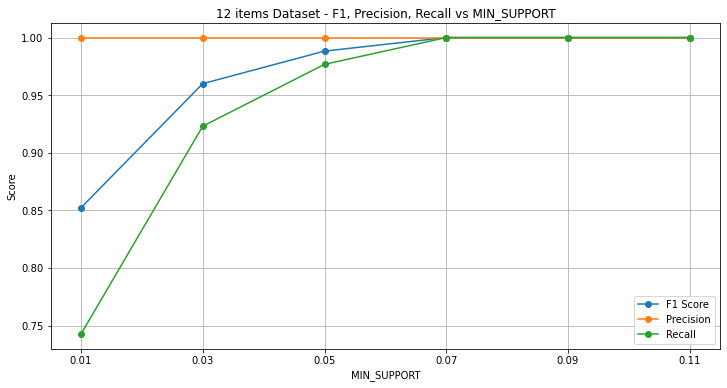

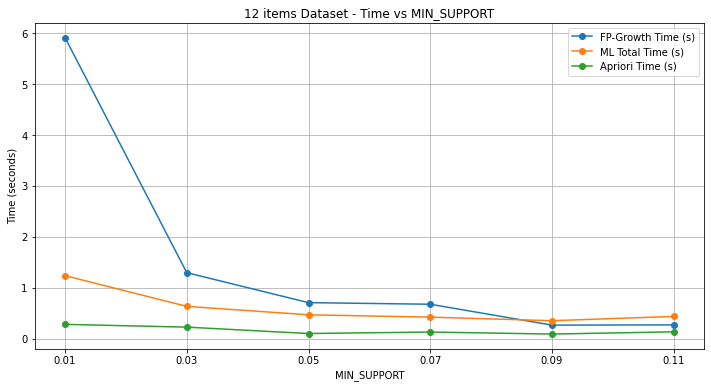

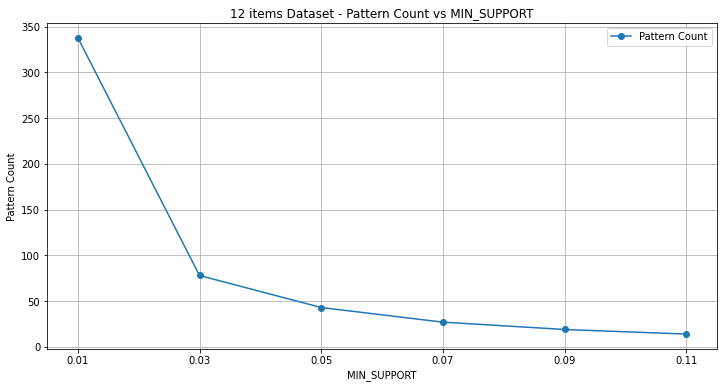

In [123]:
# 繪製圖表
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], f1_all, marker='o', label='F1 Score')
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], precision_all, marker='o', label='Precision')
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], recall_all, marker='o', label='Recall')
plt.title(f'{num_items} items Dataset - F1, Precision, Recall vs MIN_SUPPORT') # {dataset_prct*100}%
plt.xlabel('MIN_SUPPORT')
plt.ylabel('Score')
plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
plt.legend()
plt.grid()
plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}_support_vs_score.png')
plt.show()

# draw time
plt.figure(figsize=(12, 6))
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], fpg_times, marker='o', label='FP-Growth Time (s)')
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], ml_total_times, marker='o', label='ML Total Time (s)')
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], aprior_times, marker='o', label='Apriori Time (s)')
plt.title(f'{num_items} items Dataset - Time vs MIN_SUPPORT') # {dataset_prct*100}%
plt.xlabel('MIN_SUPPORT')
plt.ylabel('Time (seconds)')
plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
plt.legend()
plt.grid()
plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}_support_vs_time.png')
plt.show()

# draw pattern count
plt.figure(figsize=(12, 6))
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], pattern_count_all, marker='o', label='Pattern Count')
plt.title(f'{num_items} items Dataset - Pattern Count vs MIN_SUPPORT') # {dataset_prct*100}%
plt.xlabel('MIN_SUPPORT')
plt.ylabel('Pattern Count')
plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
plt.legend()
plt.grid()
plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}_support_vs_pattern_count.png')
plt.show()

### manual plot

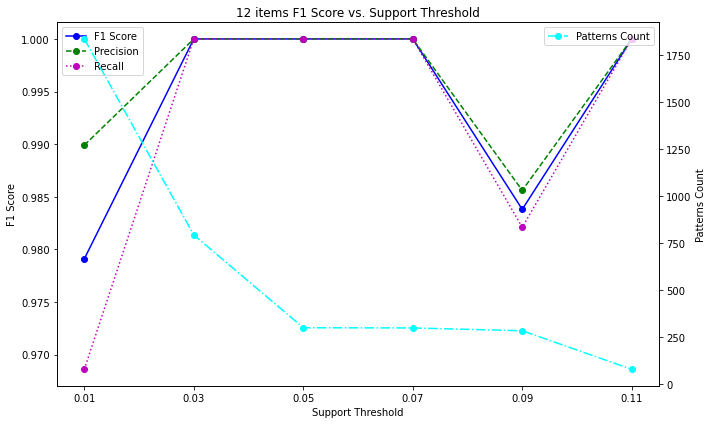

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# # 36 items F1 Score vs. Support Threshold
# support = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]

# precision = [0.9673, 0.9688, 0.9524, 0.9268, 0.9643, 0.9565]  # 假設的精確率
# recall = [0.9384,  0.9688, 1.0, 1.0, 1.0, 1.0]  # 假設的召回率
# f1_scores = [0.9526,  0.9688, 0.9756, 0.9620, 0.9818, 0.9778]  # 假設的 F1 分數

# patterns_counts = [1039, 160, 63, 41, 28, 23]  # 假設的樣式數量

# 12 items F1 Score vs. Support Threshold
support = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]

precision = [0.9899, 1.0, 1.0, 1.0, 0.9856, 1.0]  # 假設的精確率
recall = [0.9686,  1.0, 1.0, 1.0, 0.9821, 1.0]  # 假設的召回率
f1_scores = [0.9791,  1.0, 1.0, 1.0, 0.9838, 1.0]  # 假設的 F1 分數

patterns_counts = [1836, 793, 299, 298, 283, 78]  # 假設的樣式數量

plt.figure(figsize=(10, 6))
# plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# plt.plot(support, patterns_counts, marker='o', linestyle='-', color='r', label='Patterns Count')
# plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# y 同時有f1分數和patterns數量
plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# plt.plot(support_thresholds, patterns_counts, marker='o', linestyle='-', color='r', label='Patterns Count')
plt.plot(support, precision, marker='o', linestyle='--', color='g', label='Precision')
plt.plot(support, recall, marker='o', linestyle=':', color='m', label='Recall')
plt.legend()
plt.xlabel('Support Threshold')
plt.ylabel('F1 Score')
plt.xticks(support)
# plt.yticks(np.arange(0.6, 0.9, 0.02))
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.title('36 items F1 Score vs. Support Threshold')
plt.title('12 items F1 Score vs. Support Threshold')

# plot patterns counts
plt.twinx()  # 使用雙 y 軸
plt.ylabel('Patterns Count')
plt.plot(support, patterns_counts, marker='o', linestyle='-.', color='cyan', label='Patterns Count')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### compare - 給定prefix

In [115]:
# 定義想查詢的prefix
# 使用 frozenset 來匹配 itemsets
prefix_to_find = frozenset(['Milk', 'Ghee'])

# 篩選
mask = fp_results['itemsets'].apply(lambda x: x.issuperset(prefix_to_find))
filtered_fp_results = fp_results[mask]

print(f"\n--- FP-Growth patterns containing {list(prefix_to_find)} ---")
# print(filtered_fp_results.sort_values(by="support", ascending=False))

print(len(filtered_fp_results), "patterns found with prefix", list(prefix_to_find))

# count by length
# print("\n--- Count by Length of Filtered Patterns ---")
filtered_fp_results['length'] = filtered_fp_results['itemsets'].apply(lambda x: len(x))
filtered_length_counts = filtered_fp_results['length'].value_counts().sort_index()
print(filtered_length_counts)


# ML 方法生成候選樣式的程式碼
print(f"\n--- ML Method Patterns with Prefix {list(prefix_to_find)} ---")
ml_prefix_results = generate_candidate_patterns(
    beam_width=150, #120 #50, #20,
    max_length=6,
    # start_with_prefix=['Milk', 'Ghee']
    # start_with_prefix=['Ghee', 'Milk']
    start_with_prefix=list(prefix_to_find)
)
# print(ml_prefix_results)
# ml_prefix_results 進行驗證
MIN_SUPPORT = 0.01
ml_prefix_results = validate_patterns(ml_prefix_results, min_support_count=MIN_SUPPORT)
# print(len(ml_prefix_results))


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-115-8aa182dda504>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_fp_results['length'] = filtered_fp_results['itemsets'].apply(lambda x: len(x))



--- FP-Growth patterns containing ['Ghee', 'Milk'] ---
220 patterns found with prefix ['Ghee', 'Milk']
length
2      1
3     10
4     45
5    120
6     44
Name: count, dtype: int64

--- ML Method Patterns with Prefix ['Ghee', 'Milk'] ---
Starting generation with a specific prefix: ['Ghee', 'Milk']
Starting generation with beam_width=150, generating up to 4 new items

--- Validating Candidate Patterns ---
Found 206 frequent patterns with support >= 0.01 in 10020 transactions.
Validation ratio: 63.19%: 206/326
Length 2: 1/1 = 100.00%
Length 3: 10/10 = 100.00%
Length 4: 45/45 = 100.00%
Length 5: 120/120 = 100.00%
Length 6: 30/150 = 20.00%


In [116]:
# ML結果與 FP-Growth 的篩選結果進行比較
print("\n--- Comparing ML Method Patterns with FP-Growth Filtered Patterns ---")
# 計算 ML 方法與 FP-Growth 篩選結果的交集
# print(len(ml_prefix_results))
ml_set = set(tuple(sorted(p)) for p in ml_prefix_results)
fp_set = set(tuple(sorted(p)) for p in filtered_fp_results['itemsets'])

intersection = ml_set.intersection(fp_set)
print(f"common patterns: {len(intersection)}")
#TP, FP, FN, TN
# print(len(ml_set), "ML patterns")
TP = len(intersection)
FP = len(ml_set) - TP
FN = len(fp_set) - TP
print(f"TP: {TP}, FP: {FP}, FN: {FN}")

# precision, recall, f1_score
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
print(f"Precision: {precision:.4f}, \nRecall: {recall:.4f}, \nF1 Score: {f1_score:.4f}")

# 按長度統計交集
intersection_lengths = [len(p) for p in intersection]
intersection_length_counts = Counter(intersection_lengths)
print("\n--- Intersection Length Counts ---")   
# sort by length
intersection_length_counts = dict(sorted(intersection_length_counts.items()))
for length, count in intersection_length_counts.items():
    print(f"Length {length}: {count} patterns")



--- Comparing ML Method Patterns with FP-Growth Filtered Patterns ---
common patterns: 206
TP: 206, FP: 0, FN: 14
Precision: 1.0000, 
Recall: 0.9364, 
F1 Score: 0.9671

--- Intersection Length Counts ---
Length 2: 1 patterns
Length 3: 10 patterns
Length 4: 45 patterns
Length 5: 120 patterns
Length 6: 30 patterns


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
